In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

In [2]:
df = pd.read_csv("Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Shape: (440, 8)

Columns:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Data Types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

First 5 Rows:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Channel: 2 unique values
Region: 3 unique values
Fresh: 433 unique values
Milk: 421 unique values
Grocery: 430 unique values
Frozen: 426 unique values
Detergents_Paper: 417 unique values
Delicassen: 403 unique values


In [8]:
product_cols = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[product_cols].copy()

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


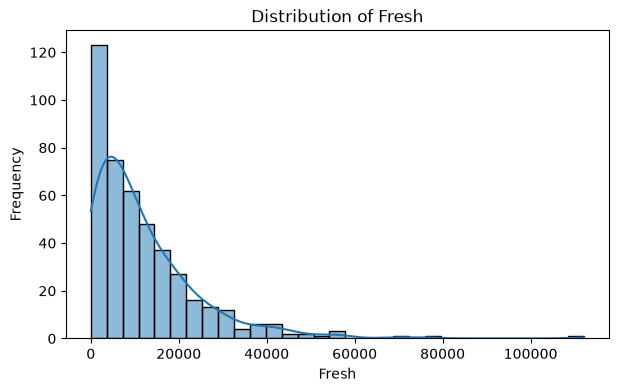

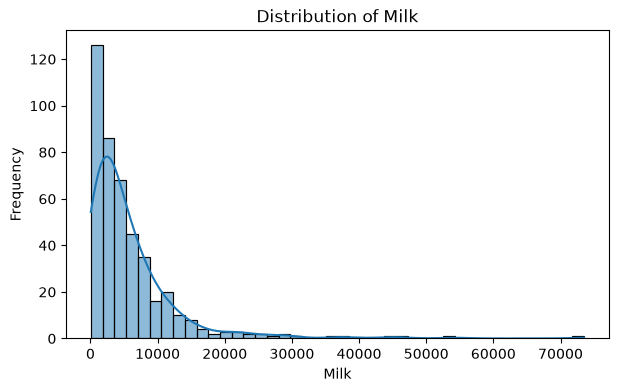

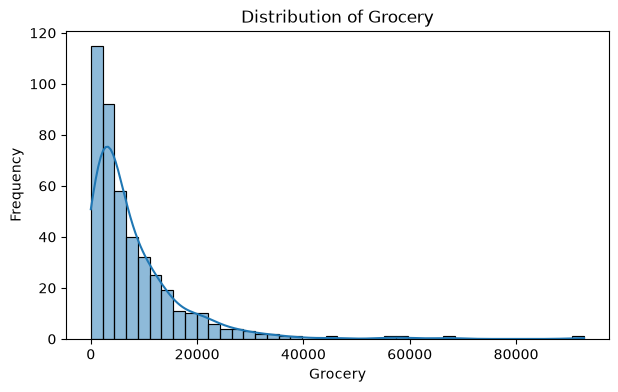

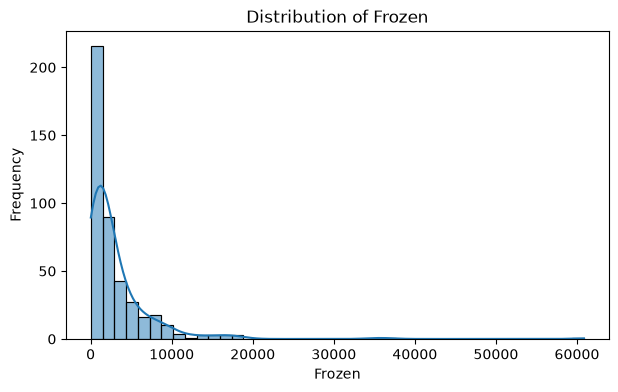

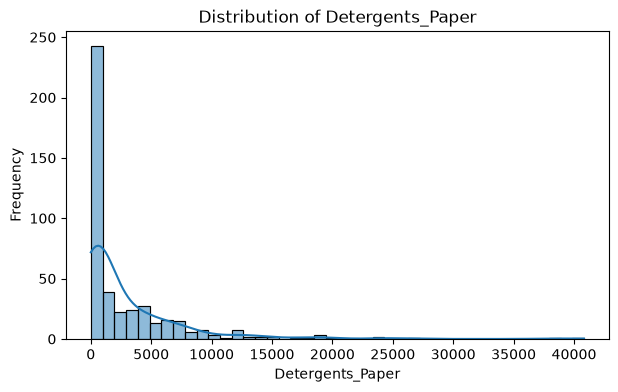

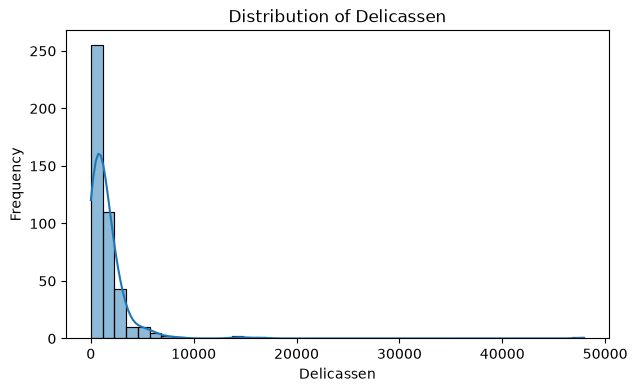

In [9]:
for col in product_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

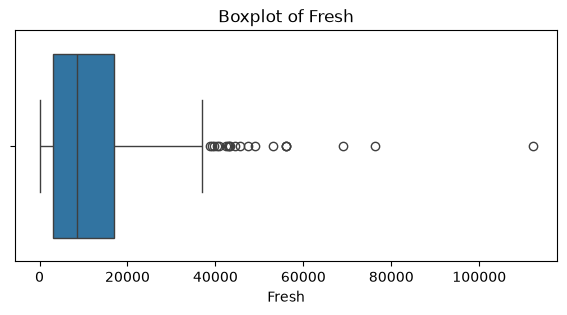

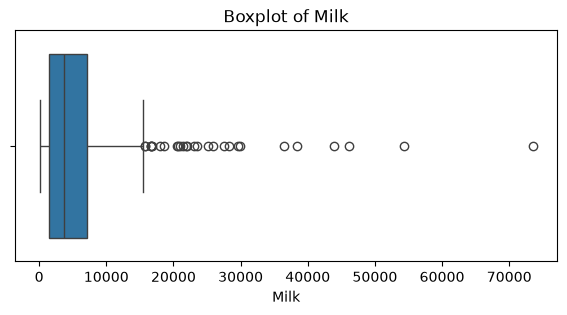

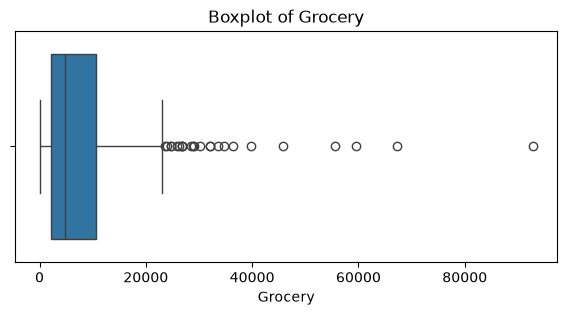

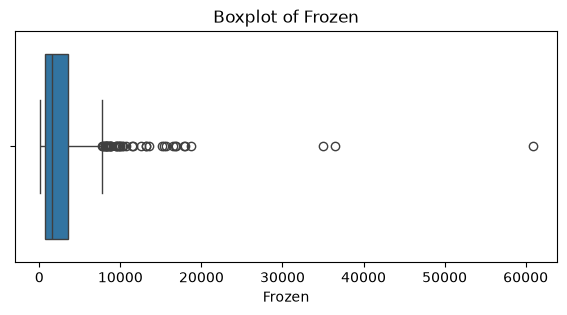

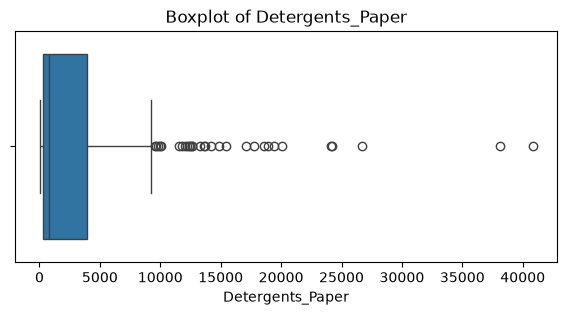

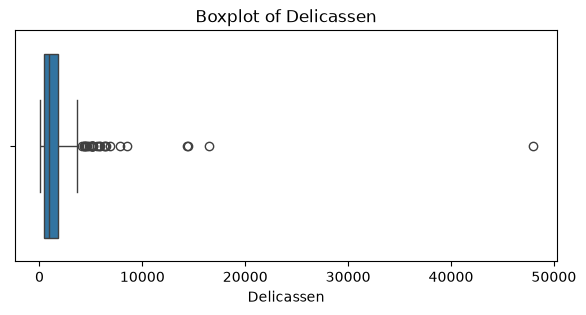

In [10]:
for col in product_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

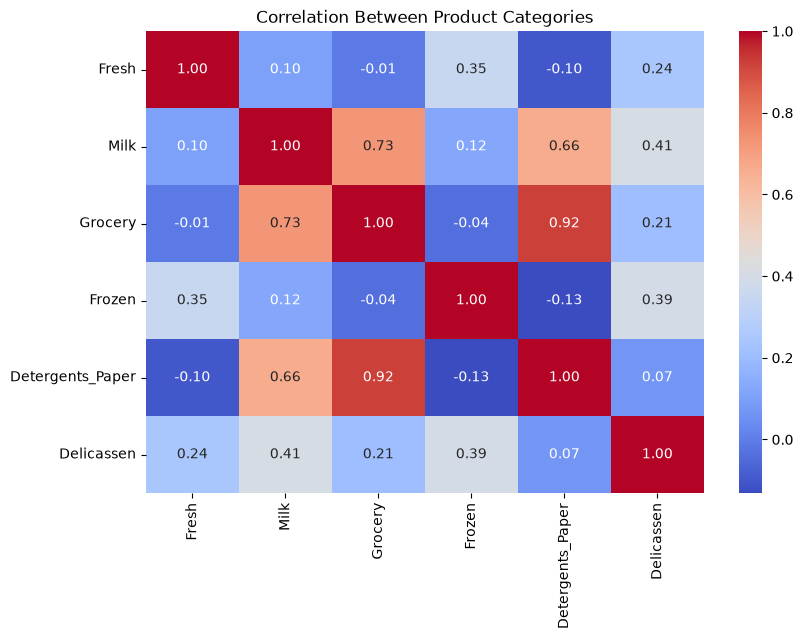

In [11]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    df[product_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Product Categories")
plt.show()

In [12]:
skewness = X.skew().sort_values(ascending=False)

print(skewness)

Delicassen          11.151586
Frozen               5.907986
Milk                 4.053755
Detergents_Paper     3.631851
Grocery              3.587429
Fresh                2.561323
dtype: float64


In [13]:
X_log = np.log1p(X)

X_log.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [14]:
print(X_log.skew().sort_values(ascending=False))

Milk               -0.224063
Detergents_Paper   -0.235961
Frozen             -0.352655
Grocery            -0.674938
Delicassen         -1.091827
Fresh              -1.575326
dtype: float64


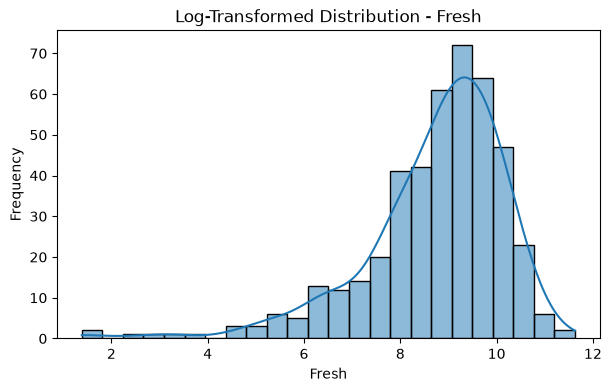

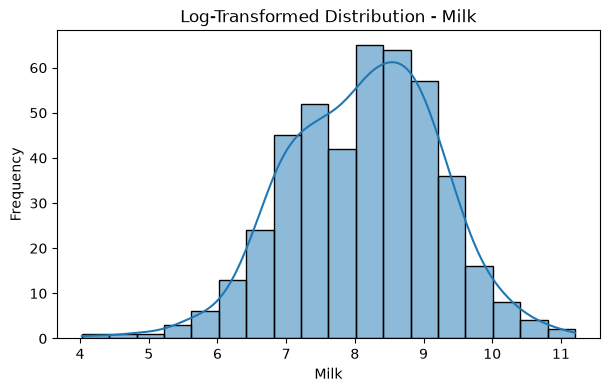

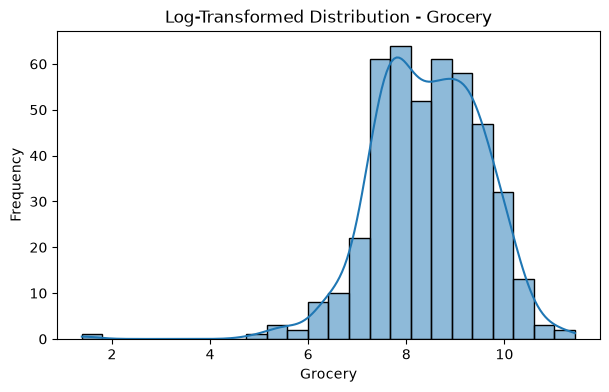

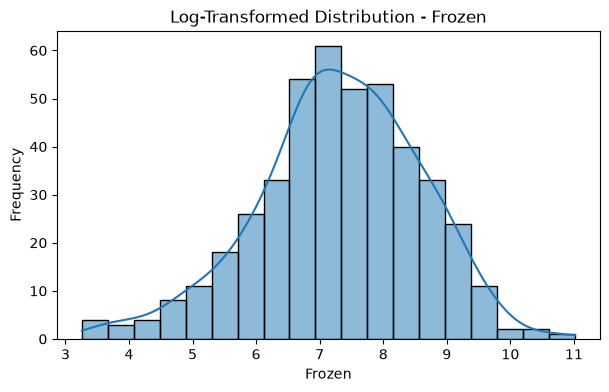

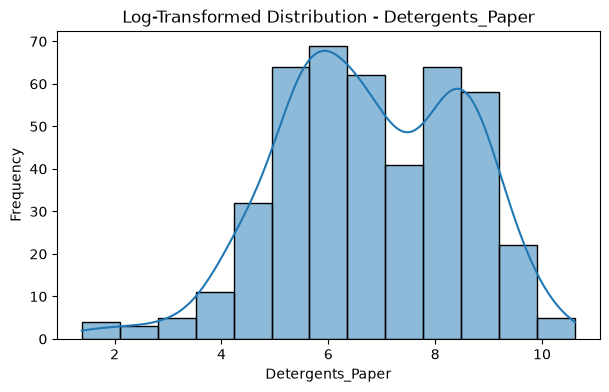

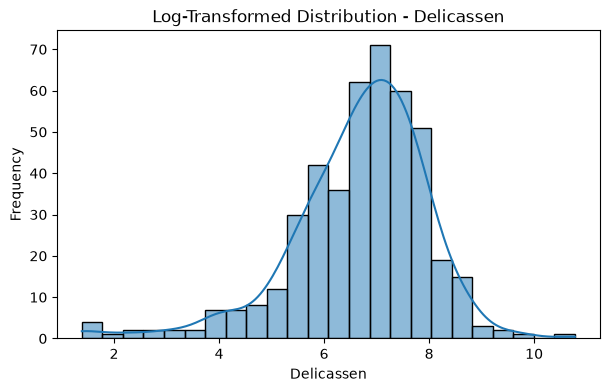

In [15]:
for col in product_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(X_log[col], kde=True)
    plt.title(f"Log-Transformed Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=product_cols
)
X_scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA features:", X_pca.shape[1])

Original features: 6
PCA features: 2


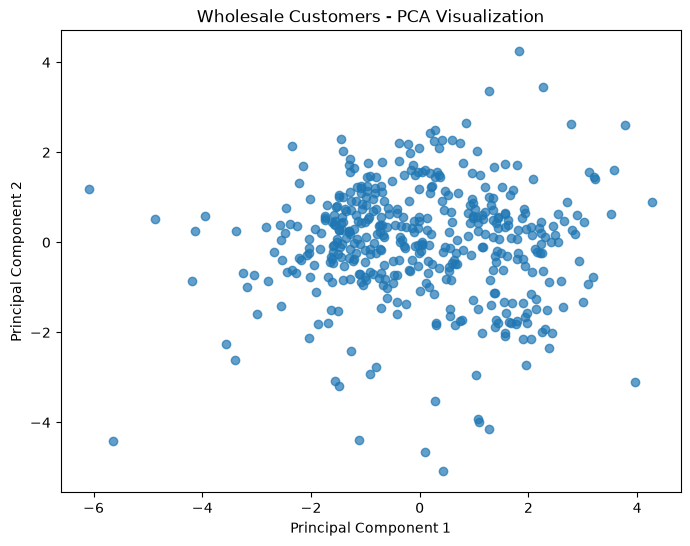

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7,
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wholesale Customers - PCA Visualization")

plt.show()

In [19]:
Z_ward = linkage(X_scaled, method="ward")

Z_complete = linkage(X_scaled, method="complete")

Z_average = linkage(X_scaled, method="average")

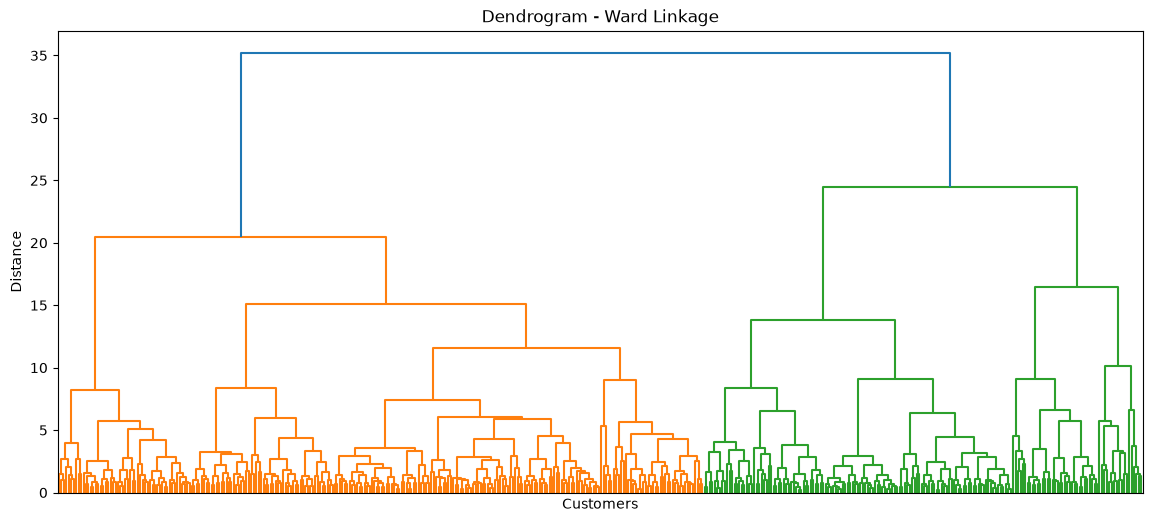

In [20]:
plt.figure(figsize=(14, 6))

dendrogram(
    Z_ward,
    no_labels=True
)

plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

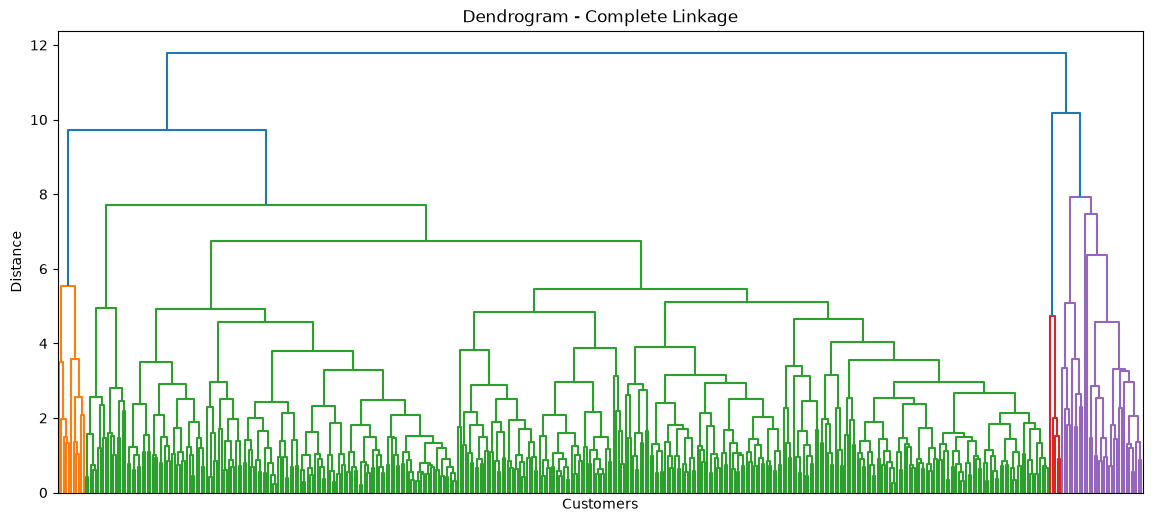

In [21]:
plt.figure(figsize=(14, 6))

dendrogram(
    Z_complete,
    no_labels=True
)

plt.title("Dendrogram - Complete Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

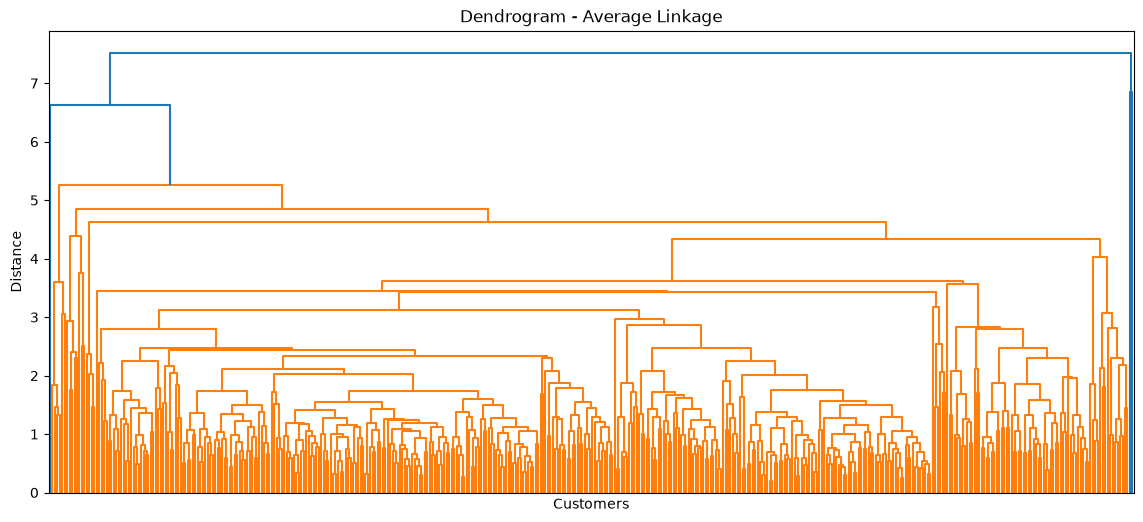

In [22]:
plt.figure(figsize=(14, 6))

dendrogram(
    Z_average,
    no_labels=True
)

plt.title("Dendrogram - Average Linkage")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [23]:
ward_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

ward_labels = ward_model.fit_predict(X_scaled)

print("Ward Cluster Labels:")
print(ward_labels)

Ward Cluster Labels:
[0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1
 0 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 1
 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 1 0
 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0
 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1
 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0]


In [24]:
complete_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="complete"
)

complete_labels = complete_model.fit_predict(X_scaled)

print("Complete Cluster Labels:")
print(complete_labels)

Complete Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]


In [25]:
average_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="average"
)

average_labels = average_model.fit_predict(X_scaled)

print("Average Cluster Labels:")
print(average_labels)

Average Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


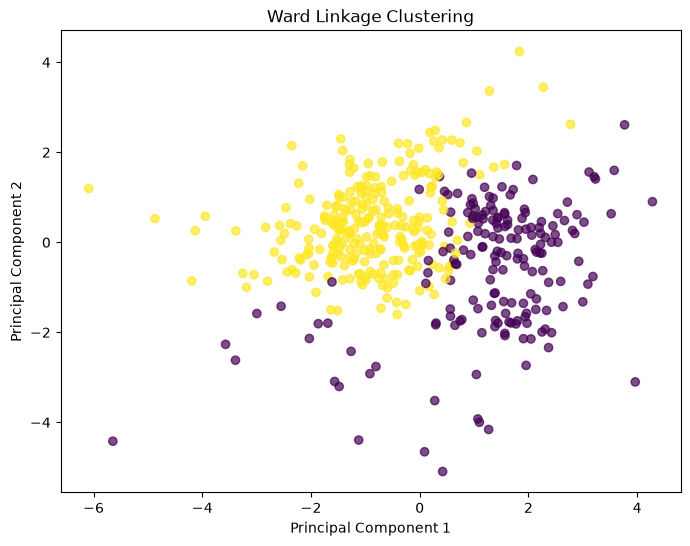

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=ward_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Ward Linkage Clustering")

plt.show()

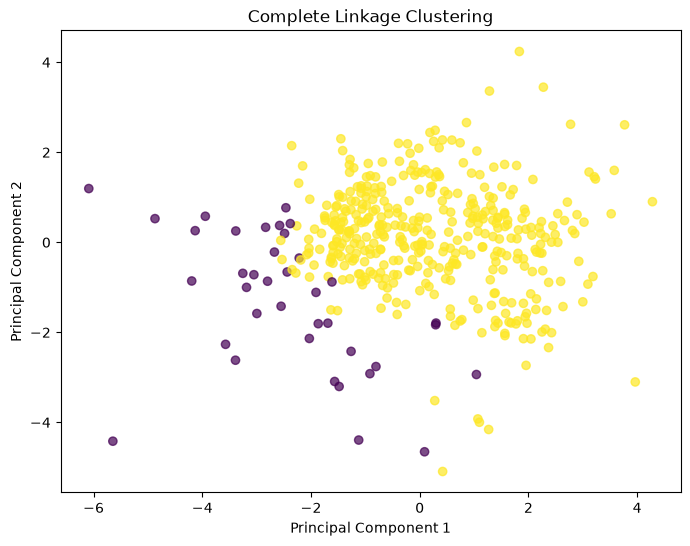

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=complete_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Complete Linkage Clustering")

plt.show()

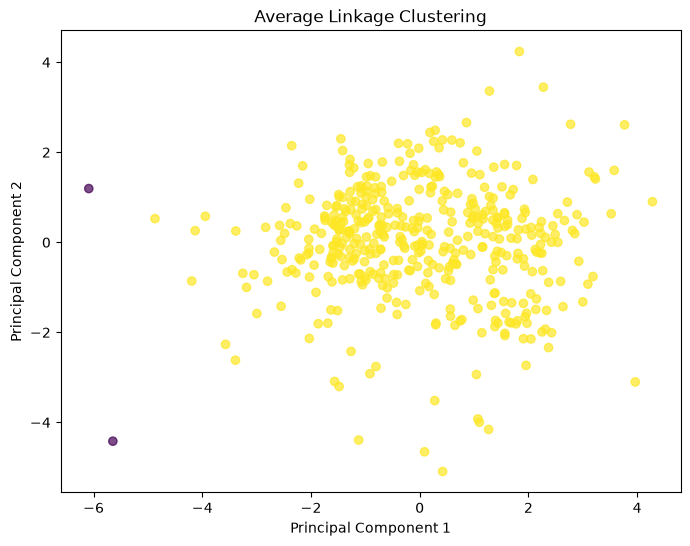

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=average_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Average Linkage Clustering")

plt.show()

In [29]:
print("WARD")
print(pd.Series(ward_labels).value_counts().sort_index())

print("\nCOMPLETE")
print(pd.Series(complete_labels).value_counts().sort_index())

print("\nAVERAGE")
print(pd.Series(average_labels).value_counts().sort_index())

WARD
0    178
1    262
Name: count, dtype: int64

COMPLETE
0     38
1    402
Name: count, dtype: int64

AVERAGE
0      2
1    438
Name: count, dtype: int64


In [30]:
from sklearn.metrics import silhouette_score

ward_silhouette = silhouette_score(
    X_scaled,
    ward_labels
)

complete_silhouette = silhouette_score(
    X_scaled,
    complete_labels
)

average_silhouette = silhouette_score(
    X_scaled,
    average_labels
)

print("Ward Silhouette Score:", round(ward_silhouette, 4))
print("Complete Silhouette Score:", round(complete_silhouette, 4))
print("Average Silhouette Score:", round(average_silhouette, 4))

Ward Silhouette Score: 0.2585
Complete Silhouette Score: 0.322
Average Silhouette Score: 0.5691


In [31]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

original_distances = pdist(
    X_scaled,
    metric="euclidean"
)

ward_coph, _ = cophenet(
    Z_ward,
    original_distances
)

complete_coph, _ = cophenet(
    Z_complete,
    original_distances
)

average_coph, _ = cophenet(
    Z_average,
    original_distances
)

print("Ward Cophenetic Correlation:", round(ward_coph, 4))
print("Complete Cophenetic Correlation:", round(complete_coph, 4))
print("Average Cophenetic Correlation:", round(average_coph, 4))

Ward Cophenetic Correlation: 0.4841
Complete Cophenetic Correlation: 0.6536
Average Cophenetic Correlation: 0.7452


In [32]:
comparison = pd.DataFrame({
    "Linkage": ["Ward", "Complete", "Average"],

    "Silhouette Score": [
        ward_silhouette,
        complete_silhouette,
        average_silhouette
    ],

    "Cophenetic Correlation": [
        ward_coph,
        complete_coph,
        average_coph
    ],

    "Cluster 0 Size": [
        sum(ward_labels == 0),
        sum(complete_labels == 0),
        sum(average_labels == 0)
    ],

    "Cluster 1 Size": [
        sum(ward_labels == 1),
        sum(complete_labels == 1),
        sum(average_labels == 1)
    ]
})

comparison

,Linkage,Silhouette Score,Cophenetic Correlation,Cluster 0 Size,Cluster 1 Size
0,Ward,0.258495,0.484077,178,262
1,Complete,0.322005,0.653562,38,402
2,Average,0.569055,0.745178,2,438


In [33]:
from sklearn.metrics import adjusted_rand_score

ward_complete_ari = adjusted_rand_score(
    ward_labels,
    complete_labels
)

ward_average_ari = adjusted_rand_score(
    ward_labels,
    average_labels
)

complete_average_ari = adjusted_rand_score(
    complete_labels,
    average_labels
)

print("Ward vs Complete:", round(ward_complete_ari, 4))
print("Ward vs Average:", round(ward_average_ari, 4))
print("Complete vs Average:", round(complete_average_ari, 4))

Ward vs Complete: 0.0111
Ward vs Average: 0.0006
Complete vs Average: 0.0838


In [34]:
ward_profile = df[product_cols].copy()

ward_profile["Cluster"] = ward_labels

ward_profile = ward_profile.groupby("Cluster")[product_cols].mean()

ward_profile.round(0)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,7561.0,9338.0,14247.0,1429.0,6215.0,1484.0
1,15016.0,3390.0,3674.0,4188.0,617.0,1553.0


In [35]:
complete_profile = df[product_cols].copy()

complete_profile["Cluster"] = complete_labels

complete_profile = complete_profile.groupby("Cluster")[product_cols].mean()

complete_profile.round(0)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,9204.0,1955.0,2875.0,2806.0,306.0,281.0
1,12265.0,6159.0,8431.0,3097.0,3125.0,1642.0


In [36]:
average_profile = df[product_cols].copy()

average_profile["Cluster"] = average_labels

average_profile = average_profile.groupby("Cluster")[product_cols].mean()

average_profile.round(0)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10510.0,596.0,70.0,2241.0,5.0,492.0
1,12007.0,5820.0,7987.0,3076.0,2895.0,1530.0


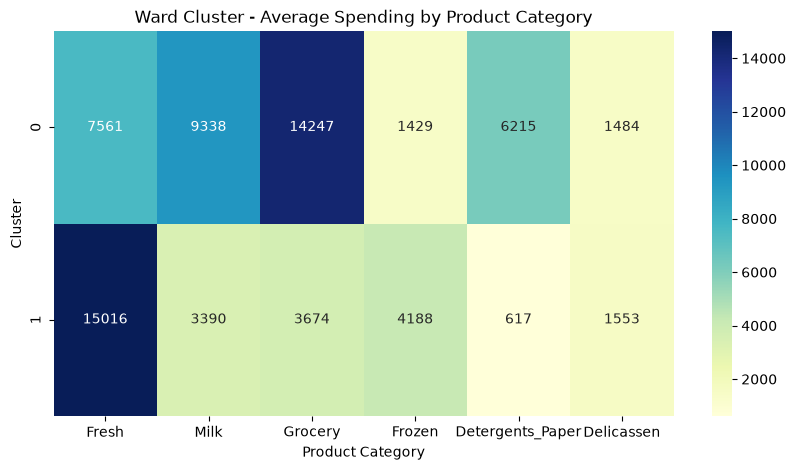

In [37]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    ward_profile,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Ward Cluster - Average Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Cluster")

plt.show()

In [38]:
final_df = df.copy()

final_df["Ward_Cluster"] = ward_labels
final_df["Complete_Cluster"] = complete_labels
final_df["Average_Cluster"] = average_labels

final_df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Ward_Cluster,Complete_Cluster,Average_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0,1,1
1,2,3,7057,9810,9568,1762,3293,1776,0,1,1
2,2,3,6353,8808,7684,2405,3516,7844,0,1,1
3,1,3,13265,1196,4221,6404,507,1788,1,1,1
4,2,3,22615,5410,7198,3915,1777,5185,1,1,1


In [39]:
final_df.to_csv(
    "Wholesale_Customers_Clustered.csv",
    index=False
)

print("File saved successfully.")

File saved successfully.
